Total labels loaded: 32036


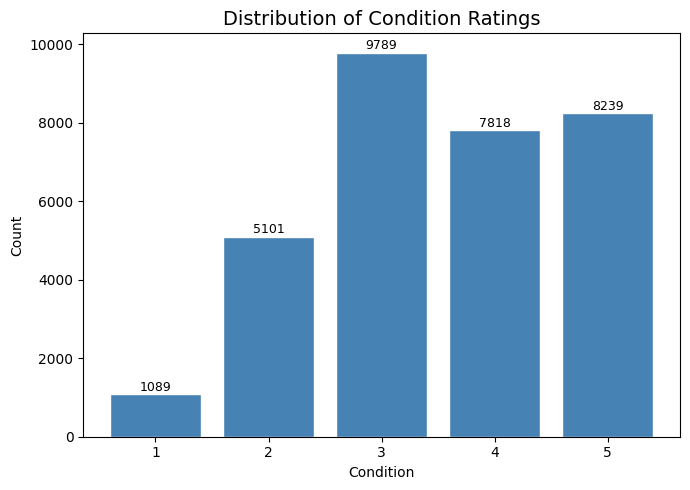

In [16]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
from collections import Counter

data_dir = Path("../data")

condition_values = []

for json_file in data_dir.rglob("*.json"):
    with open(json_file) as f:
        label = json.load(f)
    if "condition" in label:
        condition_values.append(label["condition"])

print(f"Total labels loaded: {len(condition_values)}")

condition_counts = Counter(condition_values)
condition_bins = sorted(condition_counts.keys())

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(condition_bins, [condition_counts[k] for k in condition_bins], color="steelblue", edgecolor="white")
ax.set_title("Distribution of Condition Ratings", fontsize=14)
ax.set_xlabel("Condition")
ax.set_ylabel("Count")
ax.set_xticks(condition_bins)
for x, y in zip(condition_bins, [condition_counts[k] for k in condition_bins]):
    ax.text(x, y + 5, str(y), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


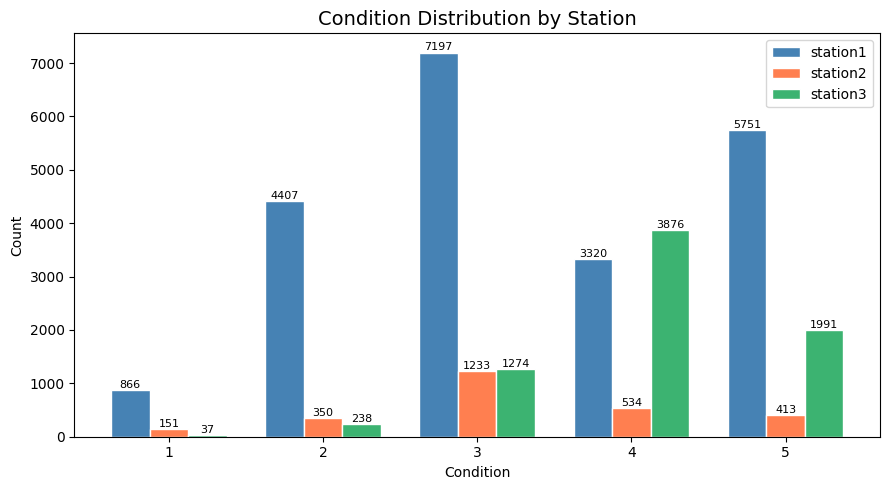

In [17]:
stations = ["station1", "station2", "station3"]
colors = {"station1": "steelblue", "station2": "coral", "station3": "mediumseagreen"}
rating_range = range(1, 6)

station_condition = {}
for station in stations:
    station_dir = Path("../data/clothing_v3") / station
    vals = []
    for json_file in station_dir.rglob("*.json"):
        with open(json_file) as f:
            label = json.load(f)
        if "condition" in label:
            vals.append(label["condition"])
    station_condition[station] = vals

import numpy as np

x = np.array(list(rating_range))
width = 0.25
offsets = [-width, 0, width]

fig, ax = plt.subplots(figsize=(9, 5))

for station, offset in zip(stations, offsets):
    counts = Counter(station_condition[station])
    heights = [counts.get(r, 0) for r in rating_range]
    bars = ax.bar(x + offset, heights, width=width, label=station,
                  color=colors[station], edgecolor="white")
    for bar, h in zip(bars, heights):
        if h > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 2, str(h),
                    ha="center", va="bottom", fontsize=8)

ax.set_title("Condition Distribution by Station", fontsize=14)
ax.set_xlabel("Condition")
ax.set_ylabel("Count")
ax.set_xticks(list(x))
ax.set_xticklabels(list(rating_range))
ax.legend()
plt.tight_layout()
plt.show()


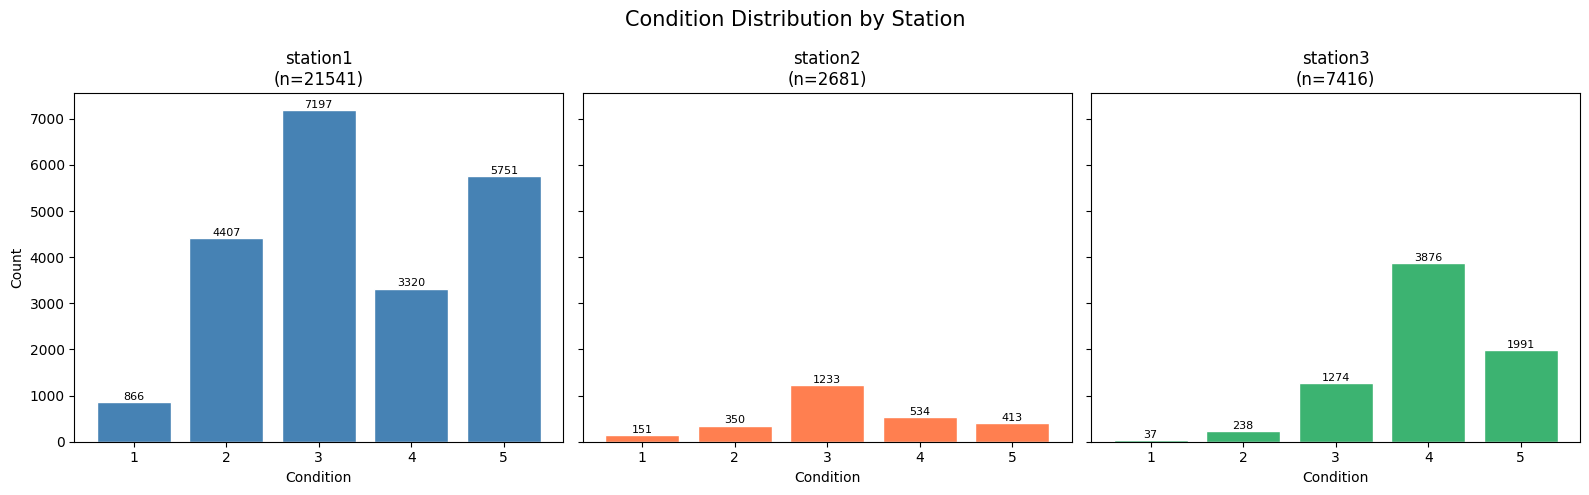

Station           n    mean    median
--------------------------------------
station1      21541    3.40         3
station2       2681    3.26         3
station3       7416    4.02         4


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for col, station in enumerate(stations):
    counts = Counter(station_condition[station])
    n = len(station_condition[station])
    heights = [counts.get(r, 0) for r in rating_range]

    ax = axes[col]
    ax.bar(list(rating_range), heights, color=colors[station], edgecolor="white")
    ax.set_title(f"{station}\n(n={n})", fontsize=12)
    ax.set_xlabel("Condition")
    ax.set_xticks(list(rating_range))
    if col == 0:
        ax.set_ylabel("Count")
    for x, y in zip(rating_range, heights):
        if y > 0:
            ax.text(x, y + 2, str(y), ha="center", va="bottom", fontsize=8)

fig.suptitle("Condition Distribution by Station", fontsize=15)
plt.tight_layout()
plt.show()

print(f"{'Station':<12} {'n':>6}  {'mean':>6}  {'median':>8}")
print("-" * 38)
for station in stations:
    vals = station_condition[station]
    mean = sum(vals) / len(vals)
    median = sorted(vals)[len(vals) // 2]
    print(f"{station:<12} {len(vals):>6}  {mean:>6.2f}  {median:>8}")


Index built: 32036 labeled items
Condition 5: 8239 items — showing 5


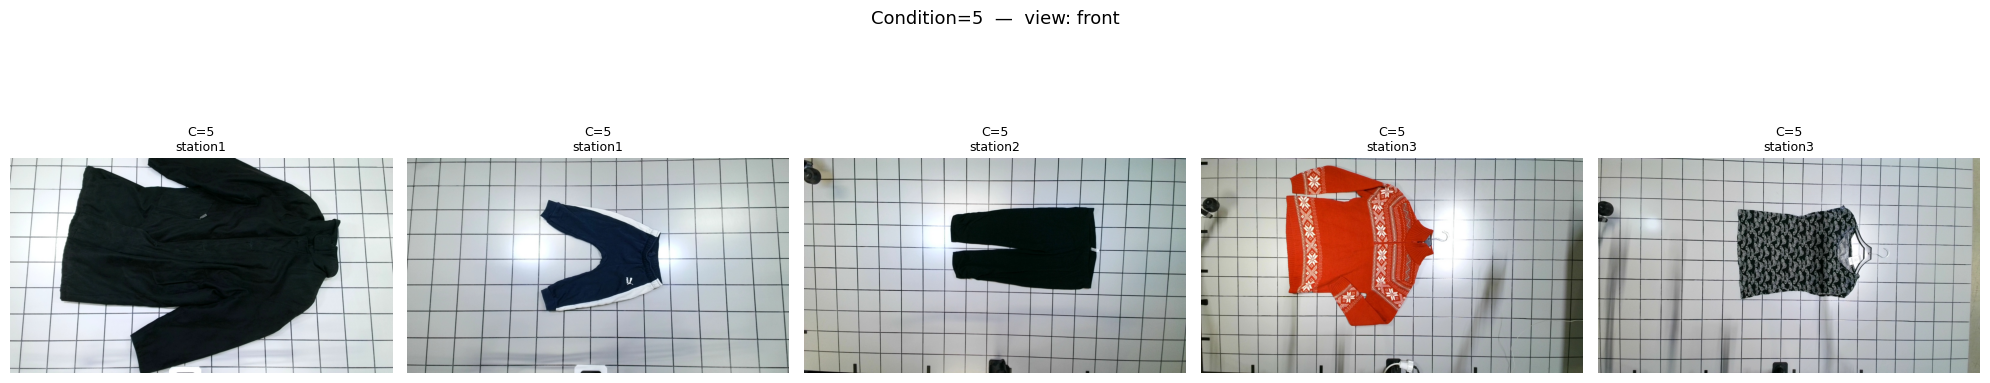

Condition 1: 1089 items — showing 5


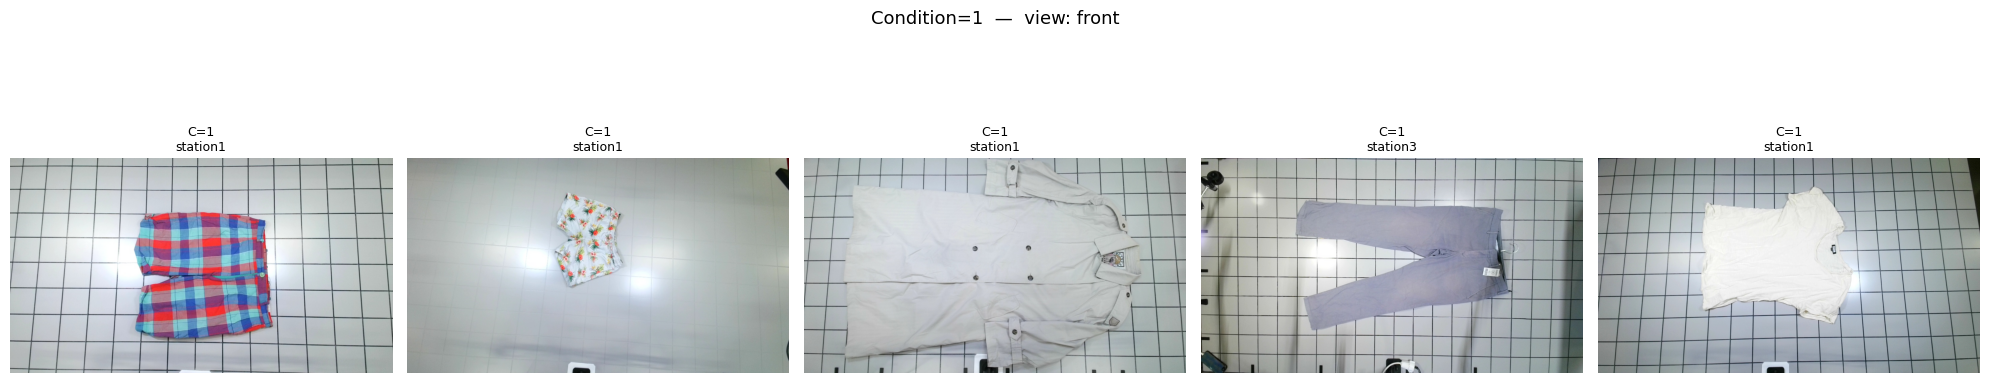

In [19]:
import random
from PIL import Image

# ── Build index of all labels ─────────────────────────────────────────────────
label_index = []  # list of dicts: {condition, folder, timestamp}

for json_file in Path("../data").rglob("labels_*.json"):
    with open(json_file) as f:
        label = json.load(f)
    cond = label.get("condition")
    if cond is not None:
        timestamp = json_file.stem.replace("labels_", "")
        label_index.append({
            "condition": cond,
            "folder":    json_file.parent,
            "timestamp": timestamp,
        })

print(f"Index built: {len(label_index)} labeled items")

# ── Sample viewer ─────────────────────────────────────────────────────────────
def show_cluster(condition: int, n: int = 5, view: str = "front"):
    """
    Display `n` random images from items whose condition == condition.

    Parameters
    ----------
    condition : int   1–5
    n         : int   number of samples to show (default 5)
    view      : str   one of 'front', 'back', 'brand' (default 'front')
    """
    cluster = [e for e in label_index if e["condition"] == condition]

    if not cluster:
        print(f"No items found for condition={condition}")
        return

    sample = random.sample(cluster, min(n, len(cluster)))
    print(f"Condition {condition}: {len(cluster)} items — showing {len(sample)}")

    fig, axes = plt.subplots(1, len(sample), figsize=(4 * len(sample), 5))
    if len(sample) == 1:
        axes = [axes]

    for ax, entry in zip(axes, sample):
        img_path = entry["folder"] / f"{view}_{entry['timestamp']}.jpg"
        if img_path.exists():
            ax.imshow(Image.open(img_path))
        else:
            ax.text(0.5, 0.5, "image\nnot found", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"C={entry['condition']}\n{entry['folder'].parent.name}", fontsize=9)
        ax.axis("off")

    fig.suptitle(f"Condition={condition}  —  view: {view}", fontsize=13)
    plt.tight_layout()
    plt.show()

# ── Change these to explore any condition ────────────────────────────────────
show_cluster(condition=5)
show_cluster(condition=1)


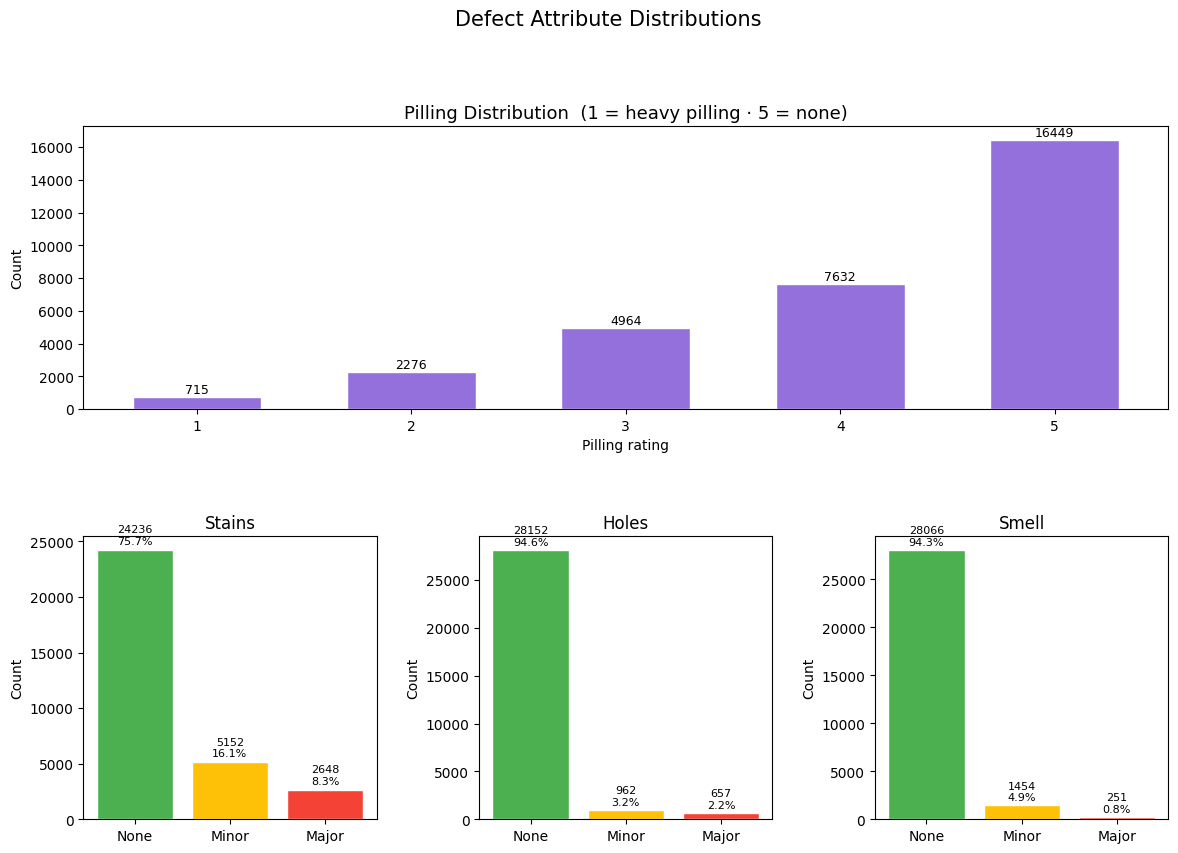

Pilling  — mean: 4.15  (n=32036)

Stains   —  7800 defective / 32036 total  (24.3%)
Holes    —  1619 defective / 29771 total  (5.4%)
Smell    —  1705 defective / 29771 total  (5.7%)


In [20]:
from collections import Counter
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np

# ── Normalise categorical fields ──────────────────────────────────────────────
def normalise_cat(value):
    """Map dirty stains/holes/smell values to None / Minor / Major."""
    v = str(value).strip().lower()
    if v in ("none", "no"):
        return "None"
    if v in ("minor", "yes"):   # 'Yes' = stain present but unlabelled severity → Minor
        return "Minor"
    if v == "major":
        return "Major"
    return "Other"

# ── Collect counts ─────────────────────────────────────────────────────────────
pilling_counts  = Counter()
stains_counts   = Counter()
holes_counts    = Counter()
smell_counts    = Counter()

for json_file in Path("../data").rglob("labels_*.json"):
    with open(json_file) as f:
        label = json.load(f)
    if "pilling" in label:
        pilling_counts[label["pilling"]] += 1
    for field, counter in [("stains", stains_counts), ("holes", holes_counts), ("smell", smell_counts)]:
        if field in label:
            counter[normalise_cat(label[field])] += 1

# ── Layout: pilling bar on top, three category bars on bottom ─────────────────
fig = plt.figure(figsize=(14, 9))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

ax_pill = fig.add_subplot(gs[0, :])   # full-width top row
ax_stain = fig.add_subplot(gs[1, 0])
ax_holes = fig.add_subplot(gs[1, 1])
ax_smell  = fig.add_subplot(gs[1, 2])

# ── Pilling (1–5) ─────────────────────────────────────────────────────────────
pill_bins   = list(range(1, 6))
pill_heights = [pilling_counts.get(b, 0) for b in pill_bins]
bars = ax_pill.bar(pill_bins, pill_heights, color="mediumpurple", edgecolor="white", width=0.6)
ax_pill.set_title("Pilling Distribution  (1 = heavy pilling · 5 = none)", fontsize=13)
ax_pill.set_xlabel("Pilling rating")
ax_pill.set_ylabel("Count")
ax_pill.set_xticks(pill_bins)
for bar, h in zip(bars, pill_heights):
    ax_pill.text(bar.get_x() + bar.get_width() / 2, h + 40, str(h),
                 ha="center", va="bottom", fontsize=9)

# ── Helper for None / Minor / Major bars ─────────────────────────────────────
cat_order  = ["None", "Minor", "Major"]
cat_colors = ["#4CAF50", "#FFC107", "#F44336"]

def draw_cat(ax, counter, title):
    heights = [counter.get(c, 0) for c in cat_order]
    total   = sum(heights)
    bars = ax.bar(cat_order, heights, color=cat_colors, edgecolor="white")
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Count")
    for bar, h in zip(bars, heights):
        pct = f"{h / total * 100:.1f}%" if total else ""
        ax.text(bar.get_x() + bar.get_width() / 2, h + total * 0.01,
                f"{h}\n{pct}", ha="center", va="bottom", fontsize=8)

draw_cat(ax_stain, stains_counts, "Stains")
draw_cat(ax_holes, holes_counts,  "Holes")
draw_cat(ax_smell, smell_counts,  "Smell")

fig.suptitle("Defect Attribute Distributions", fontsize=15, y=1.01)
plt.show()

# ── Quick summary table ───────────────────────────────────────────────────────
total = sum(pilling_counts.values())
pill_mean = sum(k * v for k, v in pilling_counts.items()) / total
print(f"Pilling  — mean: {pill_mean:.2f}  (n={total})\n")
for name, counter in [("Stains", stains_counts), ("Holes", holes_counts), ("Smell", smell_counts)]:
    n = sum(counter.values())
    defective = n - counter.get("None", 0)
    print(f"{name:<8} — {defective:>5} defective / {n} total  ({defective/n*100:.1f}%)")


In [21]:
import pandas as pd

df = pd.read_csv("../data/cleaned_metadata.csv")

# ── 1. Stratification Integrity Check ─────────────────────────────────────────
# Verify that rare labels (is_fraud_candidate, stains==2) are balanced across
# the train/test split — otherwise test-set metrics are meaningless.

def split_pct(series, label):
    """Percentage of `label` within `series`."""
    return (series == label).sum() / len(series) * 100

train = df[df["split"] == "train"]
test  = df[df["split"] == "test"]

rows = []
for name, col, val in [
    ("is_fraud_candidate == True", "is_fraud_candidate", True),
    ("stains == 2  (Major)",       "stains",             2),
    ("holes == 2   (Major)",       "holes",              2),
]:
    tr_pct  = split_pct(train[col], val)
    te_pct  = split_pct(test[col],  val)
    tr_n    = (train[col] == val).sum()
    te_n    = (test[col]  == val).sum()
    rows.append({"Label": name,
                 "Train count": tr_n, "Train %": f"{tr_pct:.3f}%",
                 "Test count":  te_n, "Test %":  f"{te_pct:.3f}%"})

check_df = pd.DataFrame(rows)
print(check_df.to_string(index=False))

print(f"\nTrain size: {len(train):,}  |  Test size: {len(test):,}")


                     Label  Train count Train %  Test count Test %
is_fraud_candidate == True           72  0.282%          23 0.360%
      stains == 2  (Major)         2079  8.138%         560 8.766%
      holes == 2   (Major)          526  2.059%         131 2.051%

Train size: 25,548  |  Test size: 6,388


Fraud candidates: 95


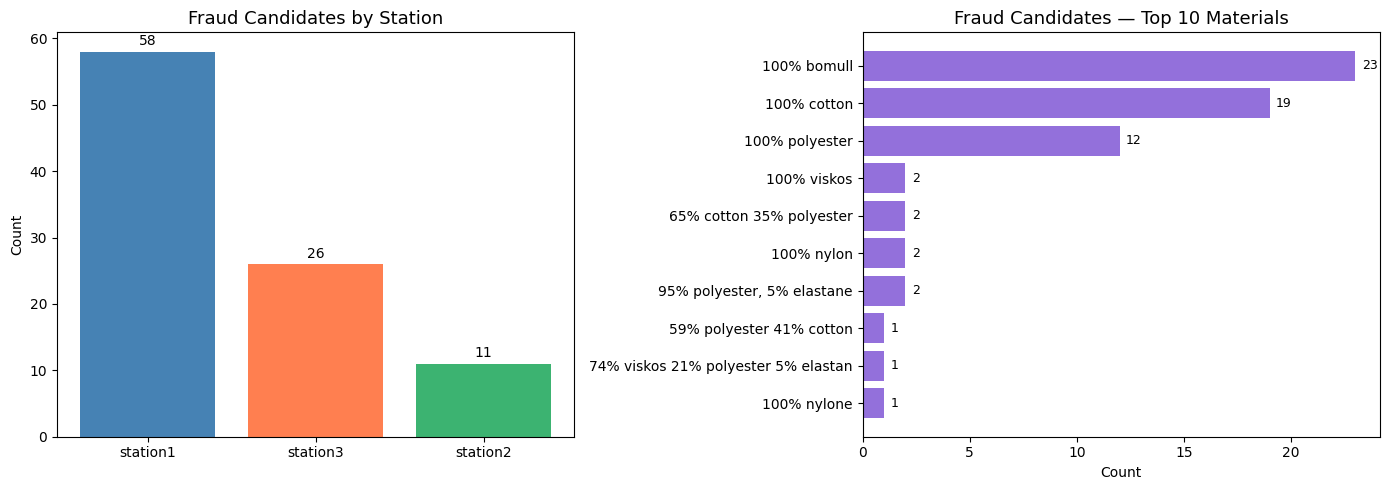


Dominant station : station1 (58/95 = 61.1%)
Dominant material: 100% bomull (23/95 = 24.2%)


In [22]:
# ── 2. Fraud Candidate Profile ─────────────────────────────────────────────────
# All 95 fraud candidates are the most valuable samples in the dataset.
# Check whether they cluster in one station or material — if so, the model
# may learn a spurious shortcut instead of detecting actual defects.

fraud = df[df["is_fraud_candidate"] == True]
print(f"Fraud candidates: {len(fraud)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Station distribution
station_cts = fraud["station"].value_counts()
axes[0].bar(station_cts.index, station_cts.values, color=["steelblue", "coral", "mediumseagreen"])
axes[0].set_title("Fraud Candidates by Station", fontsize=13)
axes[0].set_ylabel("Count")
for x, y in zip(station_cts.index, station_cts.values):
    axes[0].text(x, y + 0.5, str(y), ha="center", va="bottom", fontsize=10)

# Material distribution — top 10 materials to keep readable
mat_cts = fraud["material"].str.strip().str.lower().value_counts().head(10)
axes[1].barh(mat_cts.index, mat_cts.values, color="mediumpurple")
axes[1].set_title("Fraud Candidates — Top 10 Materials", fontsize=13)
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()
for y_idx, val in enumerate(mat_cts.values):
    axes[1].text(val + 0.3, y_idx, str(val), va="center", fontsize=9)

plt.tight_layout()
plt.show()

# Quick check: does any single station or material dominate?
top_station  = station_cts.idxmax()
top_mat      = mat_cts.idxmax()
print(f"\nDominant station : {top_station} ({station_cts.max()}/{len(fraud)} = "
      f"{station_cts.max()/len(fraud)*100:.1f}%)")
print(f"Dominant material: {top_mat} ({mat_cts.max()}/{len(fraud)} = "
      f"{mat_cts.max()/len(fraud)*100:.1f}%)")


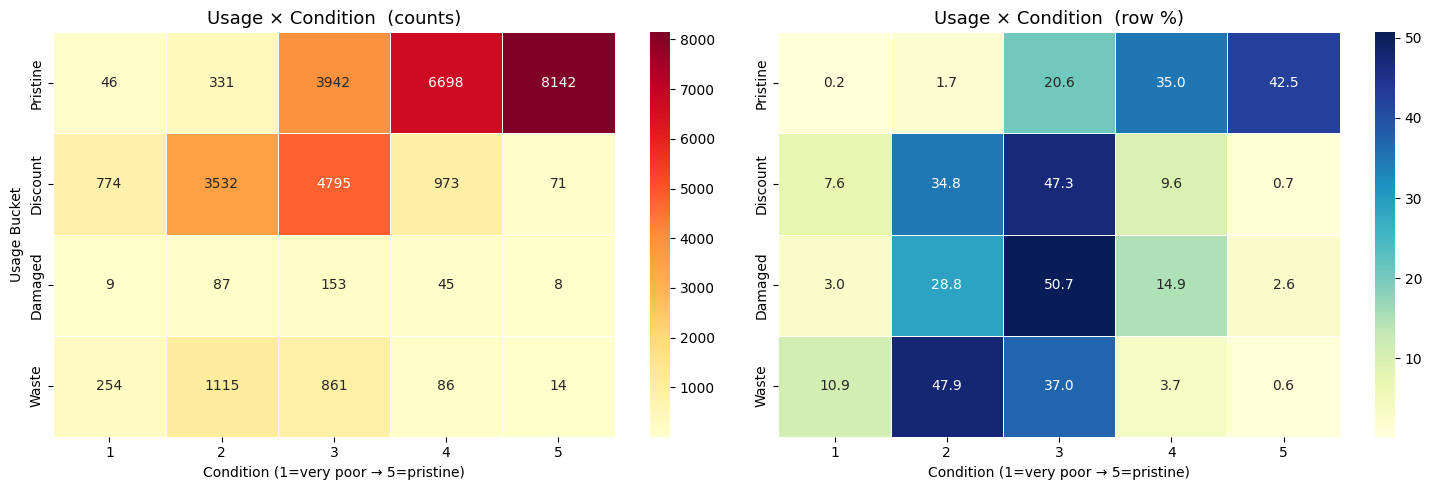

Outliers to investigate:
  Pristine with condition ≤ 2 : 377
  Waste    with condition ≥ 4 : 100


In [23]:
# ── 3. Usage Bucket vs. Condition Cross-tabulation ────────────────────────────
# Verify that human-assigned "usage" aligns with the numeric condition score.
# Flag outliers like Pristine items with Condition 1 (very poor).

import seaborn as sns

bucket_order = ["Pristine", "Discount", "Damaged", "Waste"]
ct = pd.crosstab(df["usage"], df["condition"])
ct = ct.reindex(index=[b for b in bucket_order if b in ct.index])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Heatmap of raw counts
sns.heatmap(ct, annot=True, fmt="d", cmap="YlOrRd", linewidths=0.5, ax=axes[0])
axes[0].set_title("Usage × Condition  (counts)", fontsize=13)
axes[0].set_ylabel("Usage Bucket")
axes[0].set_xlabel("Condition (1=very poor → 5=pristine)")

# Heatmap normalised per row so we see the distribution within each bucket
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
sns.heatmap(ct_pct, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=0.5, ax=axes[1])
axes[1].set_title("Usage × Condition  (row %)", fontsize=13)
axes[1].set_ylabel("")
axes[1].set_xlabel("Condition (1=very poor → 5=pristine)")

plt.tight_layout()
plt.show()

# Flag suspicious rows: Pristine with very poor condition or Waste with top condition
pristine_poor = df[(df["usage"] == "Pristine") & (df["condition"] <= 2)]
waste_good    = df[(df["usage"] == "Waste")    & (df["condition"] >= 4)]
print(f"Outliers to investigate:")
print(f"  Pristine with condition ≤ 2 : {len(pristine_poor):,}")
print(f"  Waste    with condition ≥ 4 : {len(waste_good):,}")


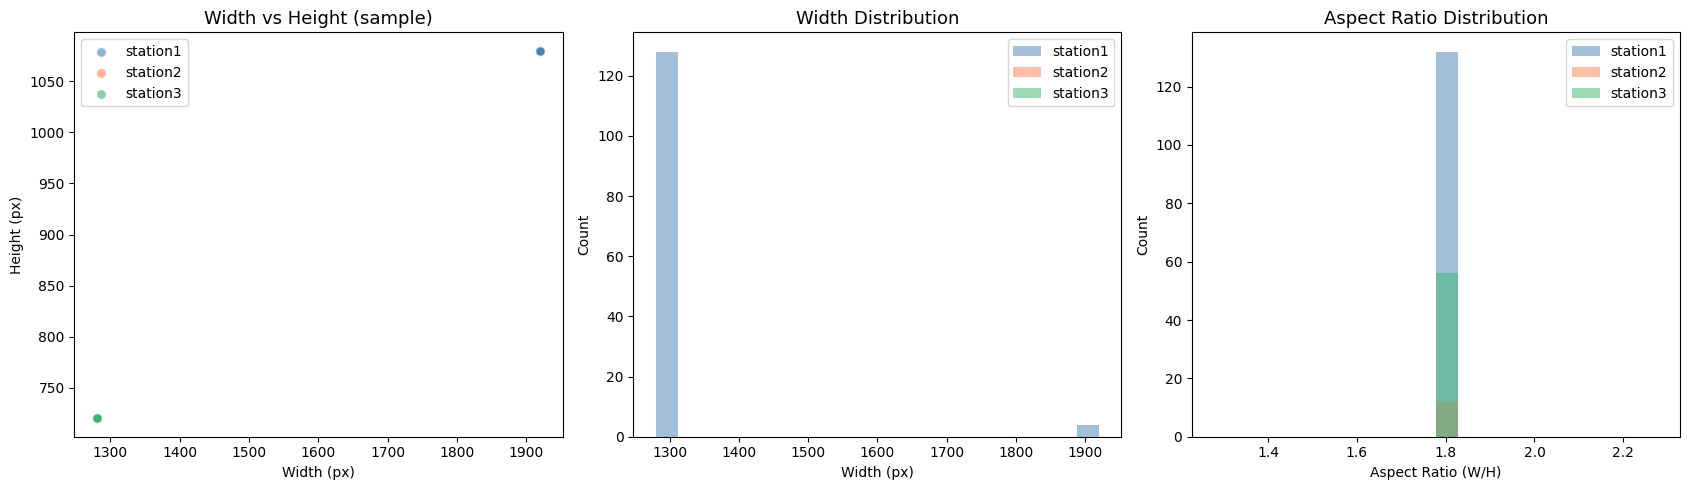

         width                      height                    aspect               
           min   max    mean    std    min   max   mean   std    min  max mean  std
station                                                                            
station1  1280  1920  1299.4  110.1    720  1080  730.9  61.9    1.8  1.8  1.8  0.0
station2  1280  1280  1280.0    0.0    720   720  720.0   0.0    1.8  1.8  1.8  0.0
station3  1280  1280  1280.0    0.0    720   720  720.0   0.0    1.8  1.8  1.8  0.0

Unique resolutions per station:
station
station1    2
station2    1
station3    1


In [24]:
# ── 4. Image Resolution & Aspect Ratio Consistency ────────────────────────────
# EfficientNet-B2 expects fixed input (e.g. 260×260). If station cameras
# differ in resolution, the model might use sharpness as a proxy for quality.
# Sample 100 images and check width × height per station.

from PIL import Image
import random

sample_rows = df.sample(n=min(100, len(df)), random_state=42)

records = []
for _, row in sample_rows.iterrows():
    for view in ("front_path", "back_path"):
        p = Path(row[view])
        if p.exists():
            with Image.open(p) as img:
                w, h = img.size
            records.append({
                "station": row["station"],
                "view":    view.replace("_path", ""),
                "width":   w,
                "height":  h,
                "aspect":  round(w / h, 3),
            })

img_df = pd.DataFrame(records)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Scatter: width vs height coloured by station
color_map = {"station1": "steelblue", "station2": "coral", "station3": "mediumseagreen"}
for station, grp in img_df.groupby("station"):
    axes[0].scatter(grp["width"], grp["height"], alpha=0.6, label=station,
                    color=color_map.get(station, "grey"), edgecolors="white", s=50)
axes[0].set_title("Width vs Height (sample)", fontsize=13)
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].legend()

# Histogram of widths by station
for station, grp in img_df.groupby("station"):
    axes[1].hist(grp["width"], bins=20, alpha=0.5, label=station,
                 color=color_map.get(station, "grey"))
axes[1].set_title("Width Distribution", fontsize=13)
axes[1].set_xlabel("Width (px)")
axes[1].set_ylabel("Count")
axes[1].legend()

# Histogram of aspect ratios by station
for station, grp in img_df.groupby("station"):
    axes[2].hist(grp["aspect"], bins=20, alpha=0.5, label=station,
                 color=color_map.get(station, "grey"))
axes[2].set_title("Aspect Ratio Distribution", fontsize=13)
axes[2].set_xlabel("Aspect Ratio (W/H)")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary table
print(img_df.groupby("station")[["width", "height", "aspect"]]
      .agg(["min", "max", "mean", "std"])
      .round(1)
      .to_string())

unique_res = img_df.groupby("station").apply(
    lambda g: g[["width", "height"]].drop_duplicates().shape[0]
)
print(f"\nUnique resolutions per station:\n{unique_res.to_string()}")
